# 04 – Modeling & Model Evaluation

This notebook covers the modeling phase of the Telco Customer Churn project.

**Goals of this notebook:**
- Train baseline classification models
- Evaluate performance using multiple metrics
- Compare Logistic Regression, Random Forest, and XGBoost
- Improve XGBoost using hyperparameter optimization with Optuna
- Visualize ROC Curve and Confusion Matrix


## 1. Load Cleaned Dataset & Prepare Train/Test Split

We start by loading the cleaned dataset created during feature engineering, separating features and labels, and performing a train/test split with stratification.

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv("../data/cleaned_telco_v2.csv")

In [3]:
X = df.drop("Churn", axis=1)
y = (df["Churn"] == "Yes").astype(int)

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

## 2. Baseline Model 1 — Logistic Regression (Balanced)

We begin with Logistic Regression as a classical linear baseline model.

- `class_weight='balanced'` helps address class imbalance (26% churn rate).
- We evaluate Accuracy, Precision, Recall, F1, and ROC AUC.

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [6]:
lr = LogisticRegression(class_weight="balanced", max_iter=1000)

In [7]:
lr.fit(X_train,y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [8]:
y_pred = lr.predict(X_test)
y_proba = lr.predict_proba(X_test)[:, 1]

In [9]:
metrics_lr = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision_Pos(Churn)": precision_score(y_test,y_pred),
    "Recall_Pos(Churn)": recall_score(y_test, y_pred),
    "F1_Pos(Churn)": f1_score(y_test,y_pred),
    "ROC_AUC": roc_auc_score(y_test, y_proba)
}
metrics_lr

{'Accuracy': 0.7395315826827538,
 'Precision_Pos(Churn)': 0.5060240963855421,
 'Recall_Pos(Churn)': 0.786096256684492,
 'F1_Pos(Churn)': 0.6157068062827226,
 'ROC_AUC': 0.8421426541631144}

## 3. Baseline Model 2 — Random Forest (Balanced)

Random Forest is a tree-based ensemble model well-suited for nonlinear patterns.

Key notes:
- `class_weight='balanced'` compensates for minority churn class
- `n_estimators=400` provides stable performance
- Good at capturing interactions between categorical-encoded features


In [10]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=400,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

In [11]:
rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=400, n_jobs=-1,
                       random_state=42)

In [12]:
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

In [13]:
metrics_rf = {
    "Accuracy": accuracy_score(y_test, y_pred_rf),
    "Precision_Pos(Churn)": precision_score(y_test, y_pred_rf),
    "Recall_Pos(Churn)": recall_score(y_test, y_pred_rf),
    "F1_Pos(Churn)": f1_score(y_test, y_pred_rf),
    "ROC_AUC": roc_auc_score(y_test, y_proba_rf)
}
metrics_rf

{'Accuracy': 0.7856635911994322,
 'Precision_Pos(Churn)': 0.6258741258741258,
 'Recall_Pos(Churn)': 0.4786096256684492,
 'F1_Pos(Churn)': 0.5424242424242425,
 'ROC_AUC': 0.8292128445581132}

## 4. Baseline Model 3 — XGBoost (scale_pos_weight)

XGBoost is a gradient boosting algorithm that usually performs well on structured datasets.

Key settings:
- `scale_pos_weight = (1-pos)/pos` to counter class imbalance
- `tree_method='hist'` to speed up training
- `learning_rate=0.05` and `max_depth=5` for stable baseline performance

In [15]:
X_train_np = X_train.astype("float32").values
X_test_np  = X_test.astype("float32").values
y_train_np = y_train.values
y_test_np  = y_test.values

from xgboost import XGBClassifier
pos = y_train_np.mean()
spw = (1 - pos) / pos

xgb = XGBClassifier(
    random_state=42,
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.9,
    colsample_bytree=0.9,
    eval_metric="logloss",
    scale_pos_weight=spw, # model churn tarafında daha hassas oluyor
    tree_method="hist",
)

xgb.fit(X_train_np, y_train_np)
y_pred_xgb = xgb.predict(X_test)
y_proba_xgb = xgb.predict_proba(X_test)[:, 1]

metrics_xgb = {
    "Accuracy": accuracy_score(y_test, y_pred_xgb),
    "Precision_Pos(Churn)": precision_score(y_test, y_pred_xgb),
    "Recall_Pos(Churn)": recall_score(y_test, y_pred_xgb),
    "F1_Pos(Churn)": f1_score(y_test, y_pred_xgb),
    "ROC_AUC": roc_auc_score(y_test, y_proba_xgb)
}
metrics_xgb

/opt/homebrew/lib/python3.11/site-packages/xgboost/data.py:312: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(dtype):
/opt/homebrew/lib/python3.11/site-packages/xgboost/data.py:314: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  elif is_categorical_dtype(dtype) and enable_categorical:
/opt/homebrew/lib/python3.11/site-packages/xgboost/data.py:345: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if is_categorical_dtype(dtype)
/opt/homebrew/lib/python3.11/site-packages/xgboost/data.py:336: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  return is_int or is_bool or is_float or is_categorical_dtype(dtype)
/opt/homebr

{'Accuracy': 0.7572746628814763,
 'Precision_Pos(Churn)': 0.5318725099601593,
 'Recall_Pos(Churn)': 0.713903743315508,
 'F1_Pos(Churn)': 0.6095890410958904,
 'ROC_AUC': 0.8315753442351909}

## 5. Baseline Model Comparison

We compare all baseline models (LR, RF, XGB) using key metrics:
- **Accuracy**: overall correctness
- **Precision (Churn)**: how many predicted churns were actually correct
- **Recall (Churn)**: how many actual churns we successfully detected
- **ROC AUC**: how well the model separates churn vs non-churn

Higher ROC AUC indicates better ranking ability.

In [16]:

rows = [("LR(balanced)", metrics_lr),
        ("RF(balanced)", metrics_rf)]
try:
    rows.append(("XGB(spw)", metrics_xgb))
except NameError:
    pass

results = pd.DataFrame([{**m, "Model": n} for n,m in rows]).set_index("Model").round(4)
results.sort_values("ROC_AUC", ascending=False)


,Accuracy,Precision_Pos(Churn),Recall_Pos(Churn),F1_Pos(Churn),ROC_AUC
Model,,,,,
LR(balanced),0.7395,0.5060,0.7861,0.6157,0.8421
XGB(spw),0.7573,0.5319,0.7139,0.6096,0.8316
RF(balanced),0.7857,0.6259,0.4786,0.5424,0.8292


## 6. ROC Curve for Baseline XGBoost

The ROC curve shows the trade-off between True Positive Rate and False Positive Rate.  
A higher curve indicates a more discriminative model.  
We also compute the AUC score for quantitative comparison.

In [17]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
fpr, tpr, thresholds = roc_curve(y_test,y_proba_xgb)
roc_auc = auc(fpr, tpr)

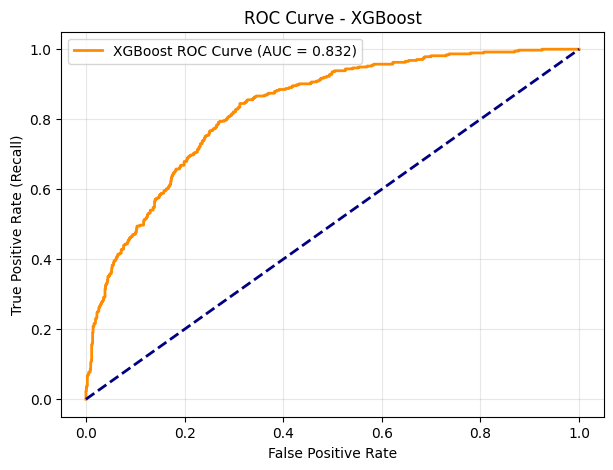

In [19]:
plt.figure(figsize = (7,5))
plt.plot(fpr,tpr, color = "darkorange", lw=2,
        label = f"XGBoost ROC Curve (AUC = {roc_auc:.3f})")
plt.plot([0,1], [0,1], color="navy", lw=2, linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve - XGBoost")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 7. Confusion Matrix – XGBoost

The confusion matrix helps understand:
- True Negatives (correctly predicted non-churn)
- False Positives (predicted churn but actually not)
- False Negatives (missed actual churns)
- True Positives (correctly predicted churns)

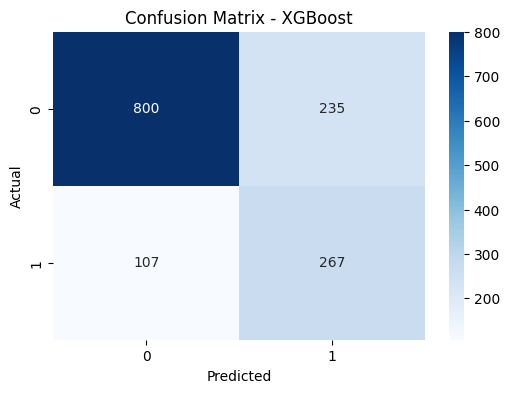

In [20]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize = (6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - XGBoost")
plt.show()

## 8. XGBoost Hyperparameter Tuning with Optuna

To improve performance, we optimize XGBoost using Optuna.

Why Optuna?
- Efficient search compared to Grid/Random Search
- Automates hyperparameter exploration
- Can maximize any evaluation metric (we use ROC AUC)

We tune:
- n_estimators
- max_depth
- learning_rate
- subsample
- colsample_bytree
- gamma
- min_child_weight

Goal: **maximize ROC AUC via stratified cross-validation**.


In [21]:
import optuna
from sklearn.model_selection import StratifiedKFold, cross_val_score
from xgboost import XGBClassifier

def objective(trial):
    # 1) Optuna'nın deneyeceği parametre aralıklarını tanımlıyoruz
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 800),
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_float("min_child_weight", 1.0, 10.0),
        "gamma": trial.suggest_float("gamma", 0.0, 5.0),
        # sabit tutacağımız parametreler:
        "random_state": 42,
        "eval_metric": "logloss",
        "tree_method": "hist",
        "scale_pos_weight": spw,
        "n_jobs": -1,
    }

    model = XGBClassifier(**params)

    # 2) Cross-validation ile ROC AUC'yi ölçüyoruz
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    auc_scores = cross_val_score(
        model,
        X_train_np,
        y_train_np,
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1
    )

    # 3) Amaç: ortalama ROC AUC'yi maksimize etmek
    return auc_scores.mean()


/opt/homebrew/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [22]:
study = optuna.create_study(
    direction="maximize",
    study_name="xgb_churn_optimization"
)

study.optimize(objective, n_trials=30, show_progress_bar=True)

print("Best ROC AUC:", study.best_trial.value)
print("Best params:")
for k, v in study.best_trial.params.items():
    print(f"  {k}: {v}")


[I 2025-11-24 11:13:56,719] A new study created in memory with name: xgb_churn_optimization
Best trial: 0. Best value: 0.848117:   3%|▏      | 1/30 [00:01<00:29,  1.01s/it]

[I 2025-11-24 11:13:57,731] Trial 0 finished with value: 0.8481173095336428 and parameters: {'n_estimators': 499, 'max_depth': 3, 'learning_rate': 0.04051231127225185, 'subsample': 0.811749956041623, 'colsample_bytree': 0.7092633769467733, 'min_child_weight': 3.465354988266292, 'gamma': 4.382377383459436}. Best is trial 0 with value: 0.8481173095336428.


Best trial: 0. Best value: 0.848117:   7%|▍      | 2/30 [00:01<00:23,  1.21it/s]

[I 2025-11-24 11:13:58,426] Trial 1 finished with value: 0.8300309345810021 and parameters: {'n_estimators': 544, 'max_depth': 7, 'learning_rate': 0.045776773881343866, 'subsample': 0.8494691526010512, 'colsample_bytree': 0.9852820484328839, 'min_child_weight': 6.129052689679008, 'gamma': 1.0968073630939839}. Best is trial 0 with value: 0.8481173095336428.


Best trial: 0. Best value: 0.848117:  10%|▋      | 3/30 [00:02<00:19,  1.38it/s]

...

[I 2025-11-24 11:14:03,128] Trial 25 finished with value: 0.8489694830380596 and parameters: {'n_estimators': 408, 'max_depth': 3, 'learning_rate': 0.025357103147247772, 'subsample': 0.6589300903186894, 'colsample_bytree': 0.6784050803206478, 'min_child_weight': 4.65824501499549, 'gamma': 2.207793280456907}. Best is trial 24 with value: 0.8498753317447377.
[I 2025-11-24 11:14:03,247] Trial 26 finished with value: 0.8493354486857293 and parameters: {'n_estimators': 350, 'max_depth': 3, 'learning_rate': 0.016039432210616277, 'subsample': 0.6178207982090673, 'colsample_bytree': 0.7244729559286291, 'min_child_weight': 5.949165237473932, 'gamma': 1.4877272755566868}. Best is trial 24 with value: 0.8498753317447377.


Best trial: 28. Best value: 0.84995:  97%|█████▊| 29/30 [00:06<00:00,  8.87it/s]

[I 2025-11-24 11:14:03,341] Trial 27 finished with value: 0.8491860206652743 and parameters: {'n_estimators': 210, 'max_depth': 4, 'learning_rate': 0.021588471249186746, 'subsample': 0.6674046503113856, 'colsample_bytree': 0.7641681741730288, 'min_child_weight': 4.780875484044659, 'gamma': 2.7327872624106555}. Best is trial 24 with value: 0.8498753317447377.
[I 2025-11-24 11:14:03,460] Trial 28 finished with value: 0.8499504694857146 and parameters: {'n_estimators': 442, 'max_depth': 3, 'learning_rate': 0.014186342400716808, 'subsample': 0.683366015082905, 'colsample_bytree': 0.6494340135454714, 'min_child_weight': 3.1988388383366786, 'gamma': 0.0743712481878187}. Best is trial 28 with value: 0.8499504694857146.


Best trial: 28. Best value: 0.84995: 100%|██████| 30/30 [00:06<00:00,  4.37it/s]

[I 2025-11-24 11:14:03,583] Trial 29 finished with value: 0.8465375825254154 and parameters: {'n_estimators': 470, 'max_depth': 3, 'learning_rate': 0.035431412293625224, 'subsample': 0.6368182931992903, 'colsample_bytree': 0.7041614402678417, 'min_child_weight': 3.136379609795238, 'gamma': 0.38181212767078093}. Best is trial 28 with value: 0.8499504694857146.
Best ROC AUC: 0.8499504694857146
Best params:
  n_estimators: 442
  max_depth: 3
  learning_rate: 0.014186342400716808
  subsample: 0.683366015082905
  colsample_bytree: 0.6494340135454714
  min_child_weight: 3.1988388383366786
  gamma: 0.0743712481878187


## 9. Evaluate Tuned XGBoost Model

After finding the best hyperparameters,  
we retrain XGBoost using the optimized settings and evaluate performance on the test set.

We compare tuned XGBoost to baseline models.

In [23]:
best_params = study.best_trial.params.copy()

# sabit tutmak istediğimiz parametreleri ekliyoruz
best_params.update({
    "random_state": 42,
    "eval_metric": "logloss",
    "tree_method": "hist",
    "scale_pos_weight": spw,
    "n_jobs": -1,
})

best_xgb = XGBClassifier(**best_params)
best_xgb.fit(X_train_np, y_train_np)

# Test set performansı
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

y_pred_best = best_xgb.predict(X_test_np)
y_proba_best = best_xgb.predict_proba(X_test_np)[:, 1]

metrics_xgb_tuned = {
    "Accuracy": accuracy_score(y_test_np, y_pred_best),
    "Precision_Pos(Churn)": precision_score(y_test_np, y_pred_best),
    "Recall_Pos(Churn)": recall_score(y_test_np, y_pred_best),
    "F1_Pos(Churn)": f1_score(y_test_np, y_pred_best),
    "ROC_AUC": roc_auc_score(y_test_np, y_proba_best),
}

metrics_xgb_tuned


{'Accuracy': 0.7437899219304471,
 'Precision_Pos(Churn)': 0.5109612141652614,
 'Recall_Pos(Churn)': 0.8101604278074866,
 'F1_Pos(Churn)': 0.6266804550155118,
 'ROC_AUC': 0.8475070397065282}

## 10. Final Model Comparison

We compare Logistic Regression, Random Forest, and Tuned XGBoost side-by-side.


In [26]:
rows = [
    ("LR(balanced)", metrics_lr),
    ("RF(balanced)", metrics_rf),
    ("XGB(tuned)", metrics_xgb_tuned)
]

results = pd.DataFrame([{**m, "Model": n} for n,m in rows]).set_index("Model").round(4)

results.sort_values("ROC_AUC",ascending=False)

,Accuracy,Precision_Pos(Churn),Recall_Pos(Churn),F1_Pos(Churn),ROC_AUC
Model,,,,,
XGB(tuned),0.7438,0.5110,0.8102,0.6267,0.8475
LR(balanced),0.7395,0.5060,0.7861,0.6157,0.8421
RF(balanced,0.7857,0.6259,0.4786,0.5424,0.8292



**Tuned XGBoost achieves the highest ROC AUC**,  
making it the best candidate for further interpretation and business decision-making.


In [30]:
import joblib
joblib.dump(best_xgb, "../models/best_xgb_model.pkl")

['../models/best_xgb_model.pkl']